<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# Unsupervised Learning – Obst (Äpfel & Orangen) mit K-Means

In diesem Notebook machen wir das **Obstbeispiel (Äpfel vs. Orangen)** noch einmal –  
diesmal aber als **Unsupervised Learning** mit **K-Means-Clustering**.

Wichtige Idee:

- Beim **Supervised Learning** hatten wir **Labels**: Banana = 2, Apfel = 1, Orange = 0
- Beim **Unsupervised Learning** verwenden wir **nur die Bilddaten**, keine Labels  
- Das Modell versucht, die Bilder in **Cluster (Gruppen)** zu trennen  


> 🔧 Hinweis zum Datensatz

Das Notebook geht davon aus, dass du den **Fruits-360**-Datensatz lokal hast, z. B.:

```
fruits-360/
  Training/
    Apple Golden 1/
    Apple Golden 2/
    ...
    Orange/
    Orange Mandarin/
    ...
```

Passe ggf. den Pfad unten an (`base_path`).

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

import random

%matplotlib inline

## 1. Pfade & Klassenordner definieren

Wir wählen alle Unterordner, deren Name **"Apple"** bzw. **"Orange"** enthält.


In [61]:
# Pfad zum Training-Ordner des Fruits-360 Datasets
base_path = Path("./data/fruits-360/Training")  # <-- ggf. anpassen

print("Basis-Pfad:", base_path.resolve())
if not base_path.exists():
    print("⚠️ Achtung: Pfad existiert nicht – bitte anpassen!")


Basis-Pfad: C:\Users\Frank\OneDrive - HTBLuVA St. Pölten\2526\DSAI\refr_dsai_script\notebooks\data\fruits-360\Training


In [62]:
# Alle Klassenordner auflisten
all_class_dirs = [d for d in base_path.iterdir() if d.is_dir()]
print("Anzahl Klassen insgesamt:", len(all_class_dirs))
print("Beispiele für Klassenordner:")
for d in all_class_dirs[:10]:
    print(" -", d.name)

Anzahl Klassen insgesamt: 4
Beispiele für Klassenordner:
 - Apple 9
 - Banana 3
 - Orange 1
 - Pear 5


In [63]:
# Apple- und Orange-Klassen auswählen
orange_dirs = [d for d in all_class_dirs if "Orange" in d.name]
apple_dirs = [d for d in all_class_dirs if "Apple" in d.name]
banana_dirs = [d for d in all_class_dirs if "Banana" in d.name]

print("\nGefundene Orange-Klassen:")
for d in orange_dirs:
    print("  -", d.name)

print("\nGefundene Apple-Klassen:")
for d in apple_dirs:
    print("  -", d.name)

print("\nGefundene Banana-Klassen:")
for d in pears_dirs:
    print("  -", d.name)


Gefundene Orange-Klassen:
  - Orange 1

Gefundene Apple-Klassen:
  - Apple 9

Gefundene Banana-Klassen:
  - Banana 3


## 2. Bilder laden und in Feature-Vektoren umwandeln

Wir machen es erstmal **einfach** und benutzen:

- verkleinerte RGB-Bilder (64×64)
- flach als Vektor (64·64·3 Features)

Das ist nicht optimal für Bildclustering, aber ideal zum Demonstrieren.


In [64]:
IMG_SIZE = (64, 64)
MAX_IMAGES_PER_CLASS = 200  # bei Bedarf anpassen oder auf None setzen

def load_image_as_vector(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    arr = np.array(img)
    return arr.flatten()  # z.B. (64*64*3, )

X = []
true_labels = []  # 1 = Apfel, 0 = Orange (nur für spätere Auswertung)
paths = []

def load_from_class_dirs(class_dirs, label):
    count = 0
    for d in class_dirs:
        for p in d.glob("*.jpg"):
            try:
                X.append(load_image_as_vector(p))
                true_labels.append(label)
                paths.append(p)
                count += 1
                if MAX_IMAGES_PER_CLASS is not None and count >= MAX_IMAGES_PER_CLASS:
                    return
            except Exception as e:
                print("Fehler bei", p, ":", e)

# Äpfel = 1, Orangen = 0 (Labels nur für spätere Auswertung, nicht fürs Clustering)
load_from_class_dirs(orange_dirs, label=0)
load_from_class_dirs(apple_dirs, label=1)
load_from_class_dirs(banana_dirs, label=2)

X = np.array(X)
true_labels = np.array(true_labels)

print("Anzahl geladener Bilder:", len(X))
print("Feature-Dimension pro Bild:", X.shape[1])

Anzahl geladener Bilder: 560
Feature-Dimension pro Bild: 12288


## 3. Ein paar Beispielbilder anzeigen

Nur zur visuellen Kontrolle, welche Bilder wir geladen haben.


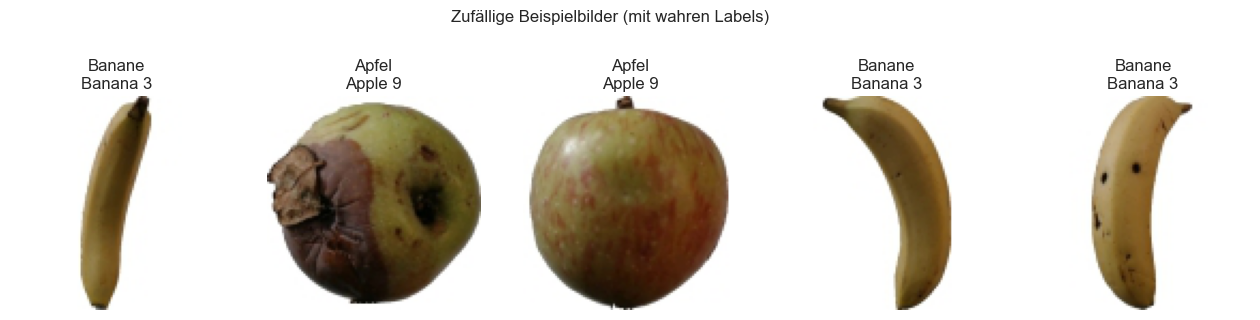

In [88]:
# Mapping der numerischen Labels zu Namen
label_map = {
    0: "Orange",
    1: "Apfel",
    2: "Banane"
}

# Anzahl zufälliger Bilder
n_show = 5
idxs = random.sample(range(len(paths)), n_show)

fig, axes = plt.subplots(1, n_show, figsize=(16, 4))

for ax, i in zip(axes, idxs):
    p = paths[i]
    lbl = true_labels[i]
    img = Image.open(p)

    ax.imshow(img)
    ax.set_title(f"{label_map[lbl]}\n{p.parent.name}")
    ax.axis("off")

plt.suptitle("Zufällige Beispielbilder (mit wahren Labels)")
plt.show()

## 4. K-Means-Clustering (unsupervised)

Jetzt machen wir **Unsupervised Learning**:

- wir verwenden **nur X**, also die Bildfeatures  
- K-Means bekommt **keine Labels**  
- wir sagen nur `n_clusters=2` (zwei Gruppen)


In [73]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X)

np.unique(cluster_labels, return_counts=True)

(array([0, 1, 2], dtype=int32), array([200, 200, 160]))

## 5. Cluster anschauen – welche Früchte landen wo?

Wir vergleichen nachträglich die gefundenen Cluster mit den **wahren Labels** (Apfel/Orange).  
Das ist nur zur Auswertung – K-Means hat diese Labels nie gesehen.


In [74]:
cm = confusion_matrix(true_labels, cluster_labels)
cm

array([[  0,   0, 160],
       [200,   0,   0],
       [  0, 200,   0]])

Die Confusion-Matrix hilft zu verstehen:

- ob z. B. **Cluster 0 ≈ Orange** und **Cluster 1 ≈ Apple** und **Cluster 2 ≈ Banana** ist
- oder umgekehrt

Da K-Means die Cluster-IDs frei vergibt, kann die Zuordnung vertauscht sein.


## 6. Beispielbilder je Cluster anzeigen

Wir zeigen z. B. die ersten paar Bilder aus Cluster 0 und Cluster 1.


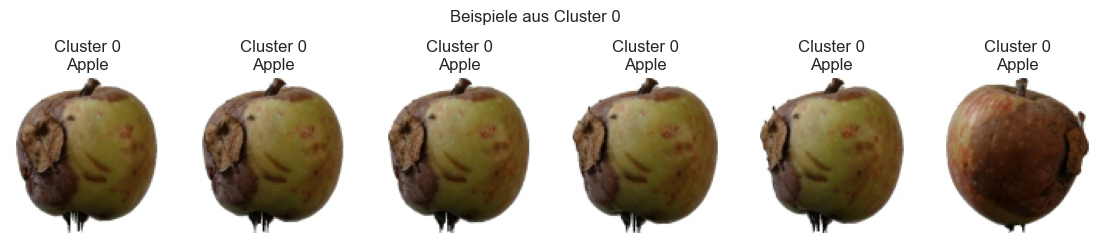

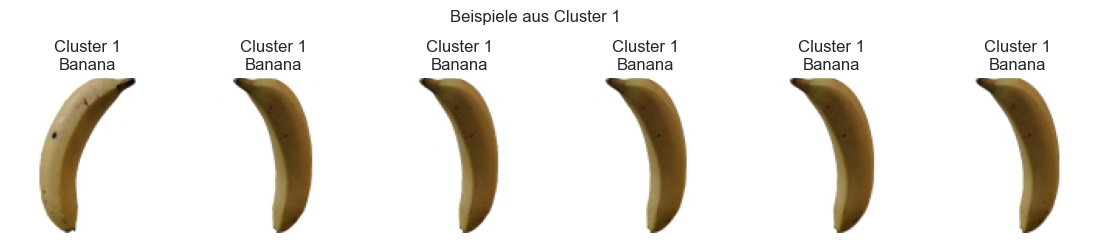

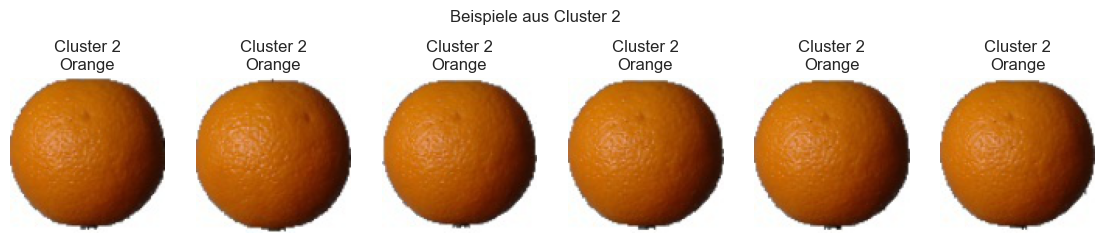

In [82]:
def show_cluster_examples(cluster_id, n=6):
    idx = np.where(cluster_labels == cluster_id)[0][:n]
    fig, axes = plt.subplots(1, len(idx), figsize=(14, 3))
    for ax, i in zip(axes, idx):
        img = Image.open(paths[i])
        lbl = true_labels[i]
        ax.imshow(img)
        clustername = ""
        if lbl==0:
            clustername = "Orange"
        elif lbl==1:
            clustername = "Apple"
        elif lbl==2:
            clustername = "Banana"
        else:
            clustername = "Fehler wurden gemacht!!"

        ax.set_title(f"Cluster {cluster_id}\n{clustername}")
        ax.axis("off")
    plt.suptitle(f"Beispiele aus Cluster {cluster_id}")
    plt.show()

show_cluster_examples(0, n=6)
show_cluster_examples(1, n=6)
show_cluster_examples(2, n=6)

## 7. Fazit

In diesem Notebook haben wir gesehen:

- **Unsupervised Learning** heißt: Das Modell sieht **keine Labels**, nur Daten.
- Mit **K-Means** können wir Bilder in Gruppen einteilen (Cluster).
- Im Obstbeispiel versucht K-Means, Äpfel und Orangen anhand der Pixelwerte zu trennen.
- Die Cluster-IDs (0, 1) sind **nur Nummern** – wir interpretieren sie erst im Nachhinein durch Vergleich mit den echten Labels.

Mögliche Erweiterungen:

- Statt Rohpixeln nur **Farbstatistiken** (z. B. Durchschnitts-RGB) als Features nutzen
- Mehr Fruchtarten dazunehmen (z. B. Bananen → k=3)
- PCA zur Dimensionsreduktion + dann K-Means auf den ersten Komponenten


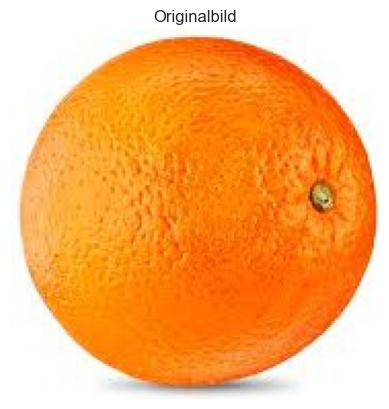

Dein Bild wurde zugeordnet zu Cluster: 2


In [90]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
#  Pfad zu deinem eigenen Bild
# -------------------------------
custom_path = "data/orange.jpg"  # <-- HIER dein Bild eintragen

# -------------------------------
# 2. Bild laden & preprocessen
# -------------------------------
IMG_SIZE = (64, 64)

def load_image_as_vector(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    arr = np.array(img)
    return arr.flatten()

# Bild laden
img = Image.open(custom_path)
plt.imshow(img)
plt.axis("off")
plt.title("Originalbild")
plt.show()

# in Vektor umwandeln
vec = load_image_as_vector(custom_path).reshape(1, -1)

# -------------------------------
# 3. Cluster-Vorhersage
# -------------------------------
cluster_id = kmeans.predict(vec)[0]

print("Dein Bild wurde zugeordnet zu Cluster:", cluster_id)
